In [24]:
import pandas as pd
import numpy as np
import pymaid
import navis
import networkx
import os
from datetime import datetime
import random
from tqdm import tqdm
import json
import re
import logging

import trimesh
from sklearn.decomposition import PCA
import plotly.express as px

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import seaborn as sns
from scipy.spatial import ConvexHull

import plotly.graph_objects as go

import networkx as nx
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, BoundaryNorm


### plot setup

In [2]:
######################################################
##################### PLOT SETUP #####################
######################################################

# set up color map
colMap = pd.read_csv('./colormap.csv')
# Prepare color dict
color_dict_type = colMap.set_index('type')['type_color'].to_dict()


# Create a directory to save the plots
save_dir = os.path.join(os.getcwd(), 'plots')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory created: {save_dir}")
else:
    print(f"Directory already exists: {save_dir}")

# Get today's date for the filenames
today = datetime.now().strftime('%d-%m-%y')

plt.rcParams['pdf.fonttype'] = 'truetype'


Directory already exists: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots


In [ ]:
### to obtain 

In [4]:
# path = 'D:/flywire_backup/cave/cat_client.json' # replace with your path

# with open(path, 'r') as f:
#     conn_file = json.load(f)
# api_token = conn_file['api_token']
# http_user = conn_file['http_user']
# http_password = conn_file['http_password']
# server = conn_file['server']

# cat_client = pymaid.CatmaidInstance(server = server, 
#                                 api_token = api_token,
#                                 caching = True,
#                                 project_id = 8,
#                                 http_user = http_user,
#                                 http_password = http_password 
#                                 )

# resolution_xyz = np.unique([list(r.values()) for r in cat_client.image_stacks.resolution], axis=0).min(0).astype(int)

# eb_m = pymaid.get_volume(['EB'], remote_instance=cat_client)
# c2_m = pymaid.get_volume(['EB_c2'], remote_instance=cat_client)

# navis.write_mesh(eb_m, '../../data/eb_m.stl')
# navis.write_mesh(c2_m, '../../data/c2_m.stl')

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


Fetching:   0%|          | 0/7 [00:00<?, ?it/s]

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\Marcel\AppData\Local\Temp\ipykernel_35140\1503693129.py:23: DtypeWarning: Columns (2,3,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  syn_df = pd.read_csv('../../data/megalopta_cx_syntable_19-04-26.csv')


In [25]:
# import local volumes obtained from CATMAID
eb_m = navis.read_mesh('../../data/eb_m.stl', output='volume')
c2_m = navis.read_mesh('../../data/c2_m.stl', output='volume')
eb_m

<navis.Volume(name=eb_m, color=(0.85, 0.85, 0.85, 0.2), vertices.shape=(5273, 3), faces.shape=(10541, 3))>

In [8]:
# read synapse table
syn_df = pd.read_csv('../../data/megalopta_cx_syntable_19-04-26.csv')
syn_df = syn_df[syn_df['roi'].str.contains(r'EB')]

syn_df = syn_df[~(syn_df['type_pre_col'].isna() & syn_df['type_post_col'].isna())] # remove nan synapses

C:\Users\Marcel\AppData\Local\Temp\ipykernel_35140\1219652089.py:2: DtypeWarning: Columns (2,3,9,10,11,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  syn_df = pd.read_csv('../../data/megalopta_cx_syntable_19-04-26.csv')


### PCA and plotting

In [9]:
# make x,y,z columns
df = syn_df.copy()
def str_to_array(s):
    if isinstance(s, str):
        s = s.strip("()")
        return np.fromstring(s, sep=',')
    return s

df['pre_coord'] = df['pre_coord'].apply(str_to_array)
df['post_coord'] = df['post_coord'].apply(str_to_array)

In [10]:
# split the pre_coord column
pre = df['pre_coord'].apply(pd.Series)
pre.columns = ['x', 'y', 'z']

post = df['post_coord'].apply(pd.Series)
post.columns = ['x', 'y', 'z']

# Concatenate back to main DataFrame
pre_df = pd.concat([df, pre], axis=1)
post_df = pd.concat([df, post], axis=1)

In [11]:
# convert from voxel coords to catmaid coords
pre_df['x'] = pre_df['x'] * 10
pre_df['y'] = pre_df['y'] * 10
pre_df['z'] = pre_df['z'] * 50

post_df['x'] = post_df['x'] * 10
post_df['y'] = post_df['y'] * 10
post_df['z'] = post_df['z'] * 50

In [12]:
pre_df['inside_c2'] = navis.in_volume(pre_df, c2_m, mode='IN')
post_df['inside_c2'] = navis.in_volume(post_df, c2_m, mode='IN')
pre_in_c2 = pre_df[pre_df['inside_c2']]
post_in_c2 = post_df[post_df['inside_c2']]

(<Figure size 720x720 with 1 Axes>, <Axes3D: >)

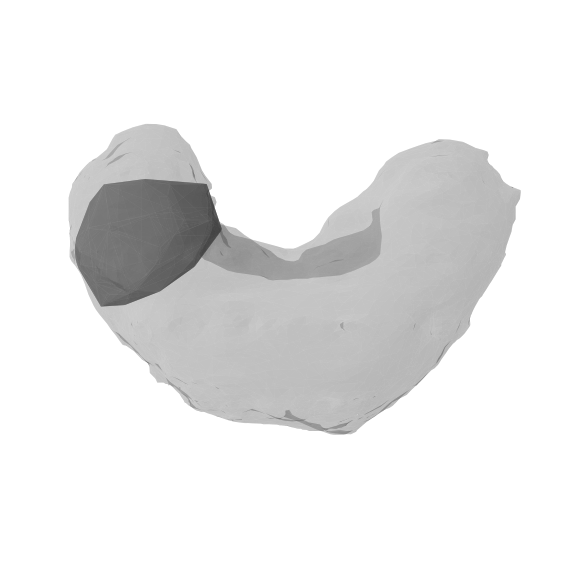

In [14]:
navis.plot2d([c2_m, eb_m], color=[(120, 120, 120, 0.6),(120, 120, 120, 0.2)])

In [ ]:
# check data in 3D
# create separate traces for each mesh with specified colors
eb = eb_m.copy()
c2 = c2_m.copy()
meshes = []

# Mesh 1: c2_m (sky blue)
verts = c2_m.vertices
faces = c2_m.faces
i, j, k = faces[:, 0], faces[:, 1], faces[:, 2]

meshes.append(go.Mesh3d(
    x=verts[:, 0],
    y=verts[:, 1],
    z=verts[:, 2],
    i=i,
    j=j,
    k=k,
    opacity=0.2,
    color='skyblue',
    name='C2 mesh',
    showscale=False
))

# Mesh 2: eb_m (grey)
verts = eb_m.vertices
faces = eb_m.faces
i, j, k = faces[:, 0], faces[:, 1], faces[:, 2]

meshes.append(go.Mesh3d(
    x=verts[:, 0],
    y=verts[:, 1],
    z=verts[:, 2],
    i=i,
    j=j,
    k=k,
    opacity=0.2,
    color='grey',
    name='EB mesh',
    showscale=False
))

ER_pre_syn = go.Scatter3d(
    x=pre_in_c2['x'],
    y=pre_in_c2['y'],
    z=pre_in_c2['z'],
    mode='markers',
    marker=dict(
        size=2,
        color=pre_in_c2['type_pre'].map(color_dict_type),  # optional color by type
        opacity=0.8
    ),
    name='synapses'
)

fig = go.Figure(data=[*meshes, ER_pre_syn])

fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='data'
    ),
    title='Synapse Locations over Mesh'
)

fig.show()


In [17]:
# figure out orientation

def close_hull(points2d):
    hull = ConvexHull(points2d)
    hv = np.append(hull.vertices, hull.vertices[0])
    return hv

def plot_projection_panel(eb_pts, c2_pts, syn_pts=None, syn_color='red', syn_alpha=0.2):
    """
    eb_pts, c2_pts: PCA-transformed Nx3 arrays
    syn_pts: optional Nx3 array of PCA-transformed synapse coords
    """
    axis_pairs = [
        ((0, 1), "PC1 vs PC2"),
        ((0, 2), "PC1 vs PC3"),
        ((1, 2), "PC2 vs PC3"),
    ]
    
    flip_options = [
        ((1, 1), "none"),
        ((-1, 1), "flip x"),
        ((1, -1), "flip y"),
        ((-1, -1), "flip xy"),
    ]
    
    fig, axes = plt.subplots(len(axis_pairs), len(flip_options), figsize=(16, 12))
    
    for i, (pair, pair_name) in enumerate(axis_pairs):
        eb_2d = eb_pts[:, pair]
        c2_2d = c2_pts[:, pair]
        
        eb_hv = close_hull(eb_2d)
        c2_hv = close_hull(c2_2d)
        
        for j, (flip, flip_name) in enumerate(flip_options):
            ax = axes[i, j]
            
            eb_plot = eb_2d * np.array(flip)
            c2_plot = c2_2d * np.array(flip)
            
            ax.plot(eb_plot[eb_hv, 0], eb_plot[eb_hv, 1], color='0.6', lw=1)
            ax.plot(c2_plot[c2_hv, 0], c2_plot[c2_hv, 1], color='k', lw=1.5)
            
            if syn_pts is not None and len(syn_pts) > 0:
                syn_2d = syn_pts[:, pair] * np.array(flip)
                ax.scatter(syn_2d[:, 0], syn_2d[:, 1], s=2, alpha=syn_alpha, c=syn_color)
            
            ax.set_title(f"{pair_name}\n{flip_name}")
            ax.set_aspect("equal")
            ax.axis("off")
    
    plt.tight_layout()
    plt.show()


D:\flywire_backup\cave\cave\lib\site-packages\sklearn\base.py:458: UserWarning:

X has feature names, but PCA was fitted without feature names

D:\flywire_backup\cave\cave\lib\site-packages\sklearn\base.py:458: UserWarning:

X has feature names, but PCA was fitted without feature names



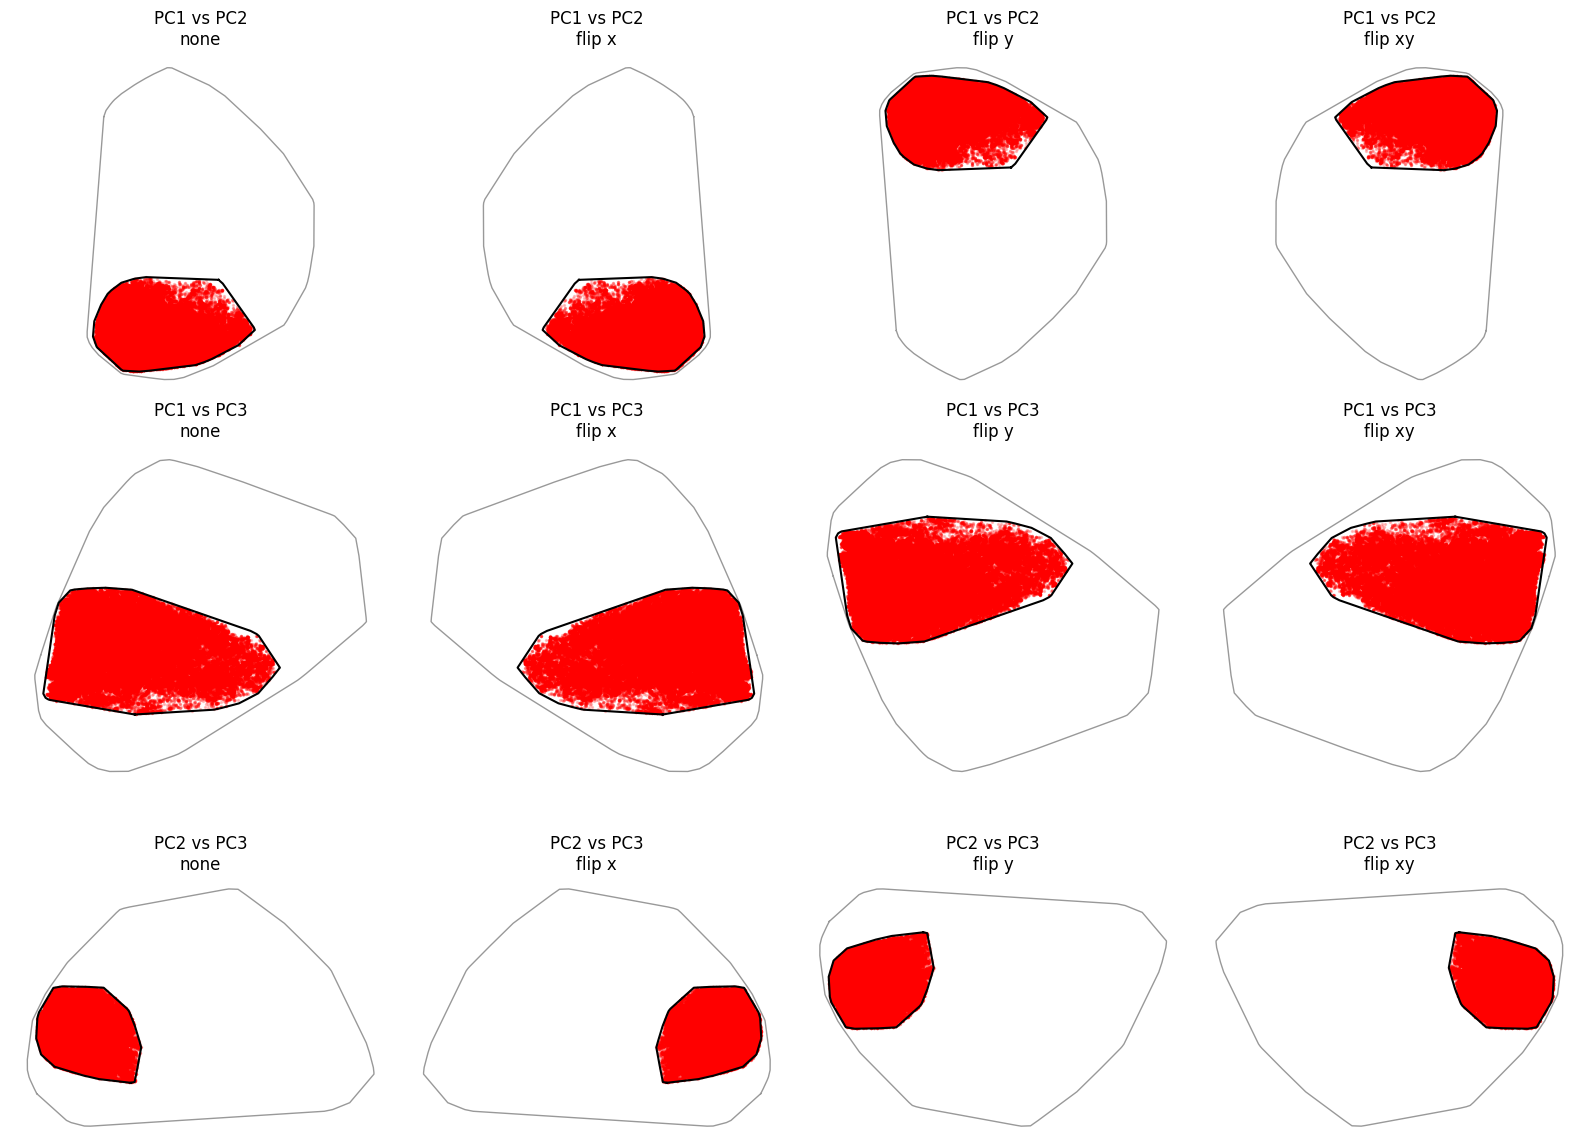

In [18]:
def center_of_mass(mesh):
    return mesh.centroid
 
pre_transformed = pre_in_c2.copy()
post_transformed = post_in_c2.copy()
eb_transformed = eb.copy()
c2_transformed = c2.copy()


# Calculate new origin
eb_origin = center_of_mass(eb_m)
pre_transformed[['x', 'y', 'z']] -= eb_origin
post_transformed[['x', 'y', 'z']] -= eb_origin
eb_transformed.apply_translation(-eb_origin)
c2_transformed.apply_translation(-eb_origin)


def align_pca(points):
    pca = PCA(n_components=3)
    pca.fit(points)
    rotated_points = pca.transform(points)
    return rotated_points, pca

# Apply PCA rotation
points_all = np.vstack((eb_transformed.vertices, c2_transformed.vertices, pre_transformed[['x','y','z']], post_transformed[['x', 'y', 'z']]))
_, pca = align_pca(points_all)

# Transform  data
eb_transformed.vertices = pca.transform(eb_transformed.vertices)
c2_transformed.vertices = pca.transform(c2_transformed.vertices)
pre_transformed[['x','y','z']] = pca.transform(pre_transformed[['x','y','z']])
post_transformed[['x','y','z']] = pca.transform(post_transformed[['x','y','z']])

plot_projection_panel(
    eb_transformed.vertices,
    c2_transformed.vertices,
    syn_pts=pre_transformed[['x', 'y', 'z']].to_numpy()
)


In [19]:
def center_of_mass(mesh):
    return mesh.centroid
 
pre_transformed = pre_in_c2.copy()
post_transformed = post_in_c2.copy()
eb_transformed = eb.copy()
c2_transformed = c2.copy()


# Calculate new origin
eb_origin = center_of_mass(eb_m)
pre_transformed[['x', 'y', 'z']] -= eb_origin
post_transformed[['x', 'y', 'z']] -= eb_origin
eb_transformed.apply_translation(-eb_origin)
c2_transformed.apply_translation(-eb_origin)


def align_pca(points):
    pca = PCA(n_components=3)
    pca.fit(points)
    rotated_points = pca.transform(points)
    return rotated_points, pca

# Apply PCA rotation
points_all = np.vstack((eb_transformed.vertices, c2_transformed.vertices, pre_transformed[['x','y','z']], post_transformed[['x', 'y', 'z']]))
_, pca = align_pca(points_all)

# Transform  data
eb_transformed.vertices = pca.transform(eb_transformed.vertices)
c2_transformed.vertices = pca.transform(c2_transformed.vertices)
pre_transformed[['x','y','z']] = pca.transform(pre_transformed[['x','y','z']])
post_transformed[['x','y','z']] = pca.transform(post_transformed[['x','y','z']])

# Rotate around current x-axis (PC1 axis)
theta = np.deg2rad(-15)   # try 15 or -15
Rx = np.array([
    [1, 0, 0],
    [0, np.cos(theta), -np.sin(theta)],
    [0, np.sin(theta),  np.cos(theta)]
])

eb_transformed.vertices = eb_transformed.vertices @ Rx.T
c2_transformed.vertices = c2_transformed.vertices @ Rx.T
pre_transformed[['x', 'y', 'z']] = pre_transformed[['x', 'y', 'z']].to_numpy() @ Rx.T
post_transformed[['x', 'y', 'z']] = post_transformed[['x', 'y', 'z']].to_numpy() @ Rx.T

# # # position data for lateral view (a bit of a silly way to do this but works)
# pre_transformed['x2d'] = pre_transformed['z']
# pre_transformed['y2d'] = pre_transformed['y']
# post_transformed['x2d'] = post_transformed['z']
# post_transformed['y2d'] = post_transformed['y']


# eb_transformed_2d = eb_transformed.vertices[:, [2, 1]]  # 0:x, 1:y, 2:z 
# cl2_2d = c2_transformed.vertices[:, [2, 1]]
pre_transformed['x2d'] = pre_transformed['x']   # PC1
pre_transformed['y2d'] = pre_transformed['z']   # PC3

post_transformed['x2d'] = post_transformed['x']
post_transformed['y2d'] = post_transformed['z']

eb_transformed_2d = eb_transformed.vertices[:, [0, 2]]   # PC1 vs PC3
cl2_2d = c2_transformed.vertices[:, [0, 2]]

# # --- Rotation matrix for 135 degrees counter-clockwise ---
# theta = np.deg2rad(135)
# R = np.array([
#     [np.cos(theta), -np.sin(theta)],
#     [np.sin(theta),  np.cos(theta)]
# ])

# # --- Rotate synapse 2D coordinates ---
# xy = pre_transformed[['x2d', 'y2d']].values
# rotated_xy = xy @ R.T
# pre_transformed['x2d'], pre_transformed['y2d'] = rotated_xy[:, 0], rotated_xy[:, 1]
# xy = post_transformed[['x2d', 'y2d']].values
# rotated_xy = xy @ R.T
# post_transformed['x2d'], post_transformed['y2d'] = rotated_xy[:, 0], rotated_xy[:, 1]


# # --- Rotate mesh outlines ---
# eb_transformed_2d = eb_transformed_2d @ R.T
# cl2_2d = cl2_2d @ R.T

# ER_pre_c2 = pre_transformed[~(pre_transformed['type_pre'].str.contains('EPG') | 
#             pre_transformed['type_pre'].str.contains('PEN') | 
#             pre_transformed['type_pre'].str.contains('PEG') |
#             pre_transformed['type_pre'].str.contains('ExR')
#            )]
# #####
# core_pre_c2 = pre_transformed[(pre_transformed['type_pre'].str.contains('EPG') | 
#             pre_transformed['type_pre'].str.contains('PEN') | 
#             pre_transformed['type_pre'].str.contains('PEG')
#            )]
# core_pre_c2 = core_pre_c2[~core_pre_c2['type_pre'].str.contains('EPGt')]
# #####
# epg_pre_c2 = pre_transformed[(pre_transformed['type_pre'].str.contains('EPG') | 
#             pre_transformed['type_pre'].str.contains('PEG')
#            )]
# epg_pre_c2 = epg_pre_c2[~epg_pre_c2['type_pre'].str.contains('EPGt')]
# #####
# pen_pre_c2 = pre_transformed[(pre_transformed['type_pre'].str.contains(r'PEN_a') | 
#             pre_transformed['type_pre'].str.contains('PEN_b')
#            )]
# #############################################
# # repeat for post
# ER_post_c2 = post_transformed[~(post_transformed['type_post'].str.contains('EPG') | 
#             post_transformed['type_post'].str.contains('PEN') | 
#             post_transformed['type_post'].str.contains('PEG') |
#             post_transformed['type_post'].str.contains('ExR')
#            )]
# #####
# core_post_c2 = post_transformed[(post_transformed['type_post'].str.contains('EPG') | 
#             post_transformed['type_post'].str.contains('PEN') | 
#             post_transformed['type_post'].str.contains('PEG')
#            )]
# core_post_c2 = core_post_c2[~core_post_c2['type_post'].str.contains('EPGt')]
# #####
# epg_post_c2 = post_transformed[(post_transformed['type_post'].str.contains('EPG') | 
#             post_transformed['type_post'].str.contains('PEG')
#            )]
# epg_post_c2 = epg_post_c2[~epg_post_c2['type_post'].str.contains('EPGt')]
# #####
# pen_post_c2 = post_transformed[(post_transformed['type_post'].str.contains(r'PEN_a') | 
#             post_transformed['type_post'].str.contains('PEN_b')
#            )]
# #####


eb_hull = ConvexHull(eb_transformed_2d)
hull = ConvexHull(cl2_2d)
hull_vertices = np.append(hull.vertices, hull.vertices[0])  # close the loop

D:\flywire_backup\cave\cave\lib\site-packages\sklearn\base.py:458: UserWarning:

X has feature names, but PCA was fitted without feature names

D:\flywire_backup\cave\cave\lib\site-packages\sklearn\base.py:458: UserWarning:

X has feature names, but PCA was fitted without feature names



In [21]:
def center_of_mass(mesh):
    return mesh.centroid


def align_pca(points):
    pca = PCA(n_components=3)
    pca.fit(points)
    return pca


def transform_points_with_pca_and_tilt(points, pca, Rx):
    pts = pca.transform(points)
    pts = pts @ Rx.T
    return pts


def make_hull_outline(points_2d):
    hull = ConvexHull(points_2d)
    hull_vertices = np.append(hull.vertices, hull.vertices[0])
    return hull, hull_vertices


def plot_kde_with_outline(data, x, y, hue, outline_2d, outline_hull_vertices,
                          palette, save_dir, title, figsize=(8, 8)):
    f, ax = plt.subplots(figsize=figsize)

    ax.plot(
        outline_2d[outline_hull_vertices, 0],
        outline_2d[outline_hull_vertices, 1],
        'k-',
        linewidth=0.5,
        label='cl2 outline'
    )
    ax.set_aspect("equal")

    if len(data) > 1:
        sns.kdeplot(
            data=data,
            x=x,
            y=y,
            fill=True,
            hue=hue,
            levels=7,
            alpha=0.7,
            bw_method='scott',
            bw_adjust=1,
            palette=palette,
            ax=ax
        )
    elif len(data) == 1:
        ax.scatter(data[x], data[y], s=20)

    ax.set_axis_off()

    file_path = os.path.join(save_dir, title)
    plt.savefig(file_path, bbox_inches='tight', pad_inches=0, format='pdf')
    plt.show()
    print(f"Plot saved: {file_path}")


# -----------------------------
# fresh copies
# -----------------------------
pre_transformed = pre_in_c2.copy(deep=True)
post_transformed = post_in_c2.copy(deep=True)
eb_transformed = eb.copy()
c2_transformed = c2.copy()

# -----------------------------
# move everything to EB-centered coordinates
# -----------------------------
eb_origin = center_of_mass(eb_m)

pre_transformed[['x', 'y', 'z']] = pre_transformed[['x', 'y', 'z']].to_numpy() - eb_origin
post_transformed[['x', 'y', 'z']] = post_transformed[['x', 'y', 'z']].to_numpy() - eb_origin

eb_transformed.apply_translation(-eb_origin)
c2_transformed.apply_translation(-eb_origin)

# -----------------------------
# fit PCA on all objects together
# -----------------------------
points_all = np.vstack((
    eb_transformed.vertices,
    c2_transformed.vertices,
    pre_transformed[['x', 'y', 'z']].to_numpy(),
    post_transformed[['x', 'y', 'z']].to_numpy()
))

pca = align_pca(points_all)

# -----------------------------
# 3D tilt about current PC1 axis
# negative 15 matched your preferred direction
# -----------------------------
theta = np.deg2rad(-15)
Rx = np.array([
    [1, 0, 0],
    [0, np.cos(theta), -np.sin(theta)],
    [0, np.sin(theta),  np.cos(theta)]
])

# -----------------------------
# transform meshes
# -----------------------------
eb_vertices_t = transform_points_with_pca_and_tilt(eb_transformed.vertices, pca, Rx)
c2_vertices_t = transform_points_with_pca_and_tilt(c2_transformed.vertices, pca, Rx)

# keep transformed mesh vertices available
eb_transformed.vertices = eb_vertices_t
c2_transformed.vertices = c2_vertices_t

# -----------------------------
# transform synapse coordinates
# -----------------------------
pre_xyz_t = transform_points_with_pca_and_tilt(
    pre_transformed[['x', 'y', 'z']].to_numpy(),
    pca,
    Rx
)
post_xyz_t = transform_points_with_pca_and_tilt(
    post_transformed[['x', 'y', 'z']].to_numpy(),
    pca,
    Rx
)

pre_transformed[['x', 'y', 'z']] = pre_xyz_t
post_transformed[['x', 'y', 'z']] = post_xyz_t

# -----------------------------
# final 2D projection
# chosen view: PC1 vs PC3
# -----------------------------
pre_transformed['x2d'] = pre_transformed['x']
pre_transformed['y2d'] = pre_transformed['z']

post_transformed['x2d'] = post_transformed['x']
post_transformed['y2d'] = post_transformed['z']

eb_transformed_2d = eb_transformed.vertices[:, [0, 2]]
cl2_2d = c2_transformed.vertices[:, [0, 2]]

# -----------------------------
# rebuild subtype tables AFTER transform
# -----------------------------
ER_pre_c2 = pre_transformed[~(
    pre_transformed['type_pre'].str.contains('EPG', na=False) |
    pre_transformed['type_pre'].str.contains('PEN', na=False) |
    pre_transformed['type_pre'].str.contains('PEG', na=False) |
    pre_transformed['type_pre'].str.contains('ExR', na=False)
)].copy()

core_pre_c2 = pre_transformed[
    pre_transformed['type_pre'].str.contains('EPG', na=False) |
    pre_transformed['type_pre'].str.contains('PEN', na=False) |
    pre_transformed['type_pre'].str.contains('PEG', na=False)
].copy()
core_pre_c2 = core_pre_c2[~core_pre_c2['type_pre'].str.contains('EPGt', na=False)].copy()

epg_pre_c2 = pre_transformed[
    pre_transformed['type_pre'].str.contains('EPG', na=False) |
    pre_transformed['type_pre'].str.contains('PEG', na=False)
].copy()
epg_pre_c2 = epg_pre_c2[~epg_pre_c2['type_pre'].str.contains('EPGt', na=False)].copy()

pen_pre_c2 = pre_transformed[
    pre_transformed['type_pre'].str.contains(r'PEN_a', na=False) |
    pre_transformed['type_pre'].str.contains('PEN_b', na=False)
].copy()

# repeat for post
ER_post_c2 = post_transformed[~(
    post_transformed['type_post'].str.contains('EPG', na=False) |
    post_transformed['type_post'].str.contains('PEN', na=False) |
    post_transformed['type_post'].str.contains('PEG', na=False) |
    post_transformed['type_post'].str.contains('ExR', na=False)
)].copy()

core_post_c2 = post_transformed[
    post_transformed['type_post'].str.contains('EPG', na=False) |
    post_transformed['type_post'].str.contains('PEN', na=False) |
    post_transformed['type_post'].str.contains('PEG', na=False)
].copy()
core_post_c2 = core_post_c2[~core_post_c2['type_post'].str.contains('EPGt', na=False)].copy()

epg_post_c2 = post_transformed[
    post_transformed['type_post'].str.contains('EPG', na=False) |
    post_transformed['type_post'].str.contains('PEG', na=False)
].copy()
epg_post_c2 = epg_post_c2[~epg_post_c2['type_post'].str.contains('EPGt', na=False)].copy()

pen_post_c2 = post_transformed[
    post_transformed['type_post'].str.contains(r'PEN_a', na=False) |
    post_transformed['type_post'].str.contains('PEN_b', na=False)
].copy()

# -----------------------------
# outlines
# -----------------------------
eb_hull, eb_hull_vertices = make_hull_outline(eb_transformed_2d)
cl2_hull, hull_vertices = make_hull_outline(cl2_2d)


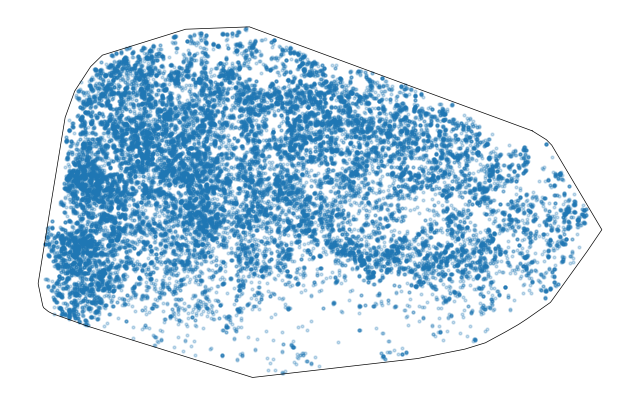

In [22]:
# -----------------------------
# optional sanity-check scatter
# run this once if things still look off
# -----------------------------
f, ax = plt.subplots(figsize=(8, 8))
ax.plot(cl2_2d[hull_vertices, 0], cl2_2d[hull_vertices, 1], 'k-', linewidth=0.5)
ax.scatter(core_pre_c2['x2d'], core_pre_c2['y2d'], s=4, alpha=0.25)
ax.set_aspect("equal")
ax.set_axis_off()
plt.show()

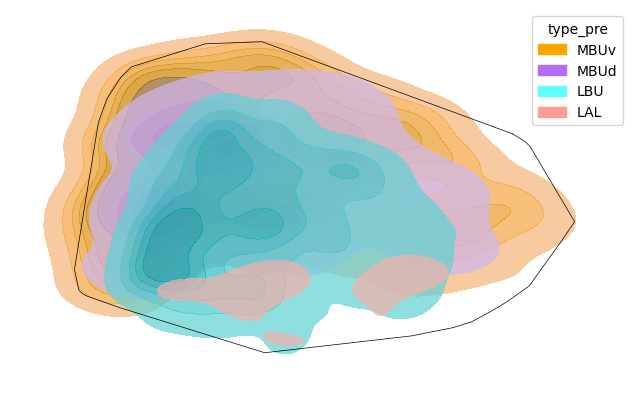

Plot saved: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots\ER_PRE_synapse_density.pdf


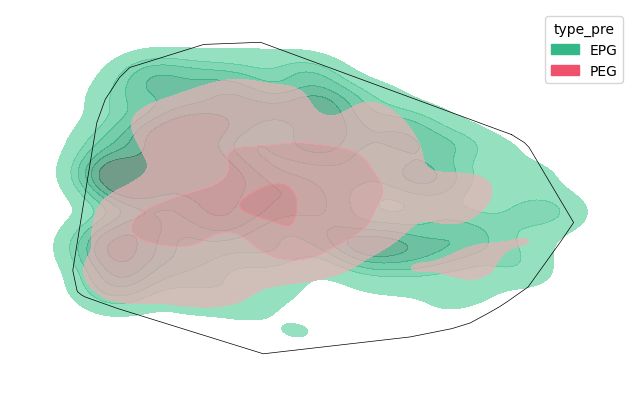

Plot saved: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots\EPGPEG_PRE_synapse_density.pdf


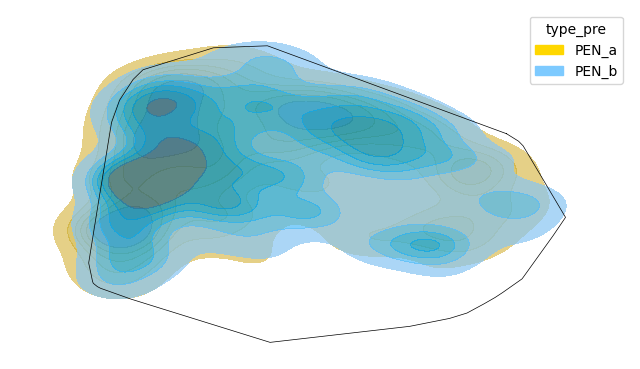

Plot saved: D:\Github\codeocean_HD_manuscript\Sayre_et_al_2026_HD\code\analysis\plots\PEN_PRE_synapse_density.pdf


In [23]:
# plots

plot_kde_with_outline(
    data=ER_pre_c2,
    x="x2d",
    y="y2d",
    hue="type_pre",
    outline_2d=cl2_2d,
    outline_hull_vertices=hull_vertices,
    palette=color_dict_type,
    save_dir=save_dir,
    title='ER_PRE_synapse_density.pdf'
)

plot_kde_with_outline(
    data=epg_pre_c2,
    x="x2d",
    y="y2d",
    hue="type_pre",
    outline_2d=cl2_2d,
    outline_hull_vertices=hull_vertices,
    palette=color_dict_type,
    save_dir=save_dir,
    title='EPGPEG_PRE_synapse_density.pdf'
)

plot_kde_with_outline(
    data=pen_pre_c2,
    x="x2d",
    y="y2d",
    hue="type_pre",
    outline_2d=cl2_2d,
    outline_hull_vertices=hull_vertices,
    palette=color_dict_type,
    save_dir=save_dir,
    title='PEN_PRE_synapse_density.pdf'
)

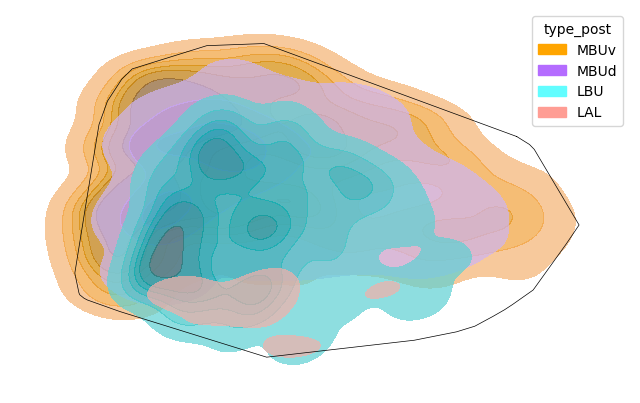

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\ER_POST_synapse_density.pdf


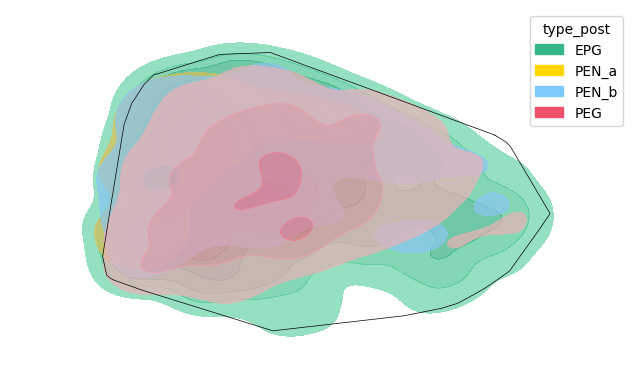

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\core-cell_POST_synapse_density.pdf


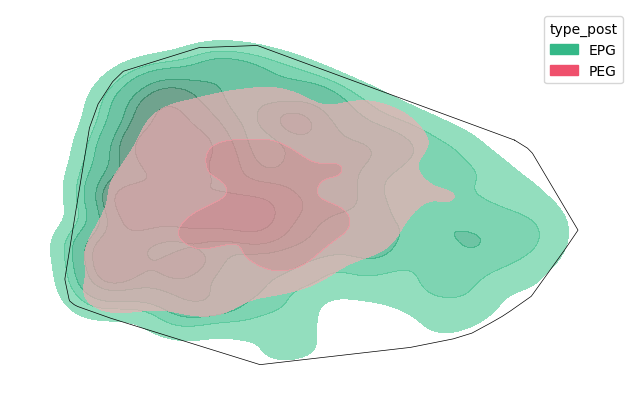

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\EPGPEG_POST_synapse_density.pdf


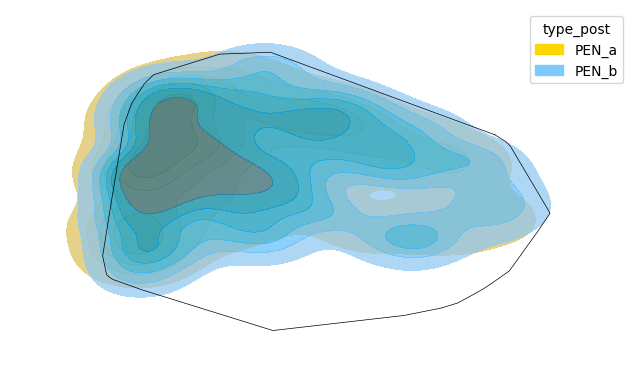

Plot saved: D:\Github\bee-ant-head-direction\analysis\plots\PEN_POST_synapse_density.pdf


In [39]:
# plots

plot_kde_with_outline(
    data=ER_post_c2,
    x="x2d",
    y="y2d",
    hue="type_post",
    outline_2d=cl2_2d,
    outline_hull_vertices=hull_vertices,
    palette=color_dict_type,
    save_dir=save_dir,
    title='ER_POST_synapse_density.pdf'
)

plot_kde_with_outline(
    data=core_post_c2,
    x="x2d",
    y="y2d",
    hue="type_post",
    outline_2d=cl2_2d,
    outline_hull_vertices=hull_vertices,
    palette=color_dict_type,
    save_dir=save_dir,
    title='core-cell_POST_synapse_density.pdf'
)

plot_kde_with_outline(
    data=epg_post_c2,
    x="x2d",
    y="y2d",
    hue="type_post",
    outline_2d=cl2_2d,
    outline_hull_vertices=hull_vertices,
    palette=color_dict_type,
    save_dir=save_dir,
    title='EPGPEG_POST_synapse_density.pdf'
)

plot_kde_with_outline(
    data=pen_post_c2,
    x="x2d",
    y="y2d",
    hue="type_post",
    outline_2d=cl2_2d,
    outline_hull_vertices=hull_vertices,
    palette=color_dict_type,
    save_dir=save_dir,
    title='PEN_POST_synapse_density.pdf'
)

In [ ]:
scatter_traces = []
for t in types:
    if t not in color_dict_type or pd.isna(t):
        continue
    df_t = pre_transformed[pre_transformed['type_pre'] == t]
    scatter_traces.append(
        go.Scatter3d(
            x=df_t['x'],
            y=df_t['y'],
            z=df_t['z'],
            mode='markers',
            marker=dict(size=2, color=color_dict_type[t]),
            name=t
        )
    )

# Optional: plot EB mesh as point cloud (use mesh3d if you have faces)
eb_mesh_trace = go.Scatter3d(
    x=eb_transformed.vertices[:, 0],
    y=eb_transformed.vertices[:, 1],
    z=eb_transformed.vertices[:, 2],
    mode='markers',
    marker=dict(size=1, color='gray', opacity=0.3),
    name='EB Mesh'
)

fig = go.Figure(data=[eb_mesh_trace] + scatter_traces)
fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='data'
    ),
    title='3D View of Synapses and EB Mesh'
)

fig.show()